# Relatividad y Gravitación
## Prof. Jorge I. Zuluaga

### Cuaderno de Clase: Geodésicas en la Métrica de Schwarzschild

## Paquetes requeridos

In [20]:
!pip install -Uq einsteinpy


[notice] A new release of pip is available: 25.1.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


In [21]:
import einsteinpy.symbolic as es
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
import pymcel as pc
from scipy.integrate import solve_ivp
import spiceypy as spy

## Ecuaciones de la geodésica

La métrica de Newton es:

$$
\mathrm{d}s^2 = \left(1-\frac{2GM}{c^2 r}\right) c^2 \mathrm{d}t^2 - \left(1-\frac{2GM}{c^2 r}\right)\mathrm{d}r^2 - r^2\mathrm{d}\theta^2 - r^2\sin^2\theta \mathrm{d}\phi^2
$$

Calculamos los símbolos de Christoffel:

In [22]:
G, M, c, T, r, teta, fi = sp.symbols('G M c T r theta phi')

gmat = np.diag([1-2*G*M/(c**2*r), -1/(1-2*G*M/(c**2*r)), -r**2, -r**2*sp.sin(teta)**2])
coordenadas = T, r, teta, fi
gmet = es.MetricTensor(gmat, coordenadas)
Gab = es.ChristoffelSymbols.from_metric(gmet)
display(gmet.tensor())
display(Gab.tensor())

[[-2*G*M/(c**2*r) + 1, 0, 0, 0], [0, -1/(-2*G*M/(c**2*r) + 1), 0, 0], [0, 0, -r**2, 0], [0, 0, 0, -r**2*sin(theta)**2]]

[[[0, G*M/(r*(-2*G*M + c**2*r)), 0, 0], [G*M/(r*(-2*G*M + c**2*r)), 0, 0, 0], [0, 0, 0, 0], [0, 0, 0, 0]], [[-G*M*(2*G*M - c**2*r)/(c**4*r**3), 0, 0, 0], [0, G*M*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2), 0, 0], [0, 0, (2*G*M - c**2*r)/c**2, 0], [0, 0, 0, (2*G*M - c**2*r)*sin(theta)**2/c**2]], [[0, 0, 0, 0], [0, 0, 1/r, 0], [0, 1/r, 0, 0], [0, 0, 0, -sin(theta)*cos(theta)]], [[0, 0, 0, 0], [0, 0, 0, 1/r], [0, 0, 0, cos(theta)/sin(theta)], [0, 1/r, cos(theta)/sin(theta), 0]]]

Ecuaciones de la geodésica:

In [23]:
xpp = sp.symbols(r'\ddot{T} \ddot{r} \ddot{\theta} \ddot{\phi}')
xp = sp.symbols(r'\dot{T} \dot{r} \dot{\theta} \dot{\phi}')

for sigma in range(4):
    ecuacion = 0
    for mu in range(4):
        for nu in range(4):
            ecuacion += -Gab[sigma, mu, nu] * xp[mu] * xp[nu]

    ecuacion = sp.Eq(xpp[sigma],ecuacion)
    display(ecuacion)

Eq(\ddot{T}, -2*G*M*\dot{T}*\dot{r}/(r*(-2*G*M + c**2*r)))

Eq(\ddot{r}, G*M*\dot{T}**2*(2*G*M - c**2*r)/(c**4*r**3) - G*M*\dot{r}**2*(2*G*M - c**2*r)/(c**4*r**3*(-2*G*M/(c**2*r) + 1)**2) - \dot{\phi}**2*(2*G*M - c**2*r)*sin(theta)**2/c**2 - \dot{\theta}**2*(2*G*M - c**2*r)/c**2)

Eq(\ddot{\theta}, \dot{\phi}**2*sin(theta)*cos(theta) - 2*\dot{\theta}*\dot{r}/r)

Eq(\ddot{\phi}, -2*\dot{\phi}*\dot{\theta}*cos(theta)/sin(theta) - 2*\dot{\phi}*\dot{r}/r)

In [24]:
def edg_schwarzschild(tau, Ys, G, M, c):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys

    rs = 2 * G * M / c**2  # radio de Schwarzschild

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi

    # Ecuaciones geodésicas: d²x^σ/dτ² = -Γ^σ_{μν} ẋ^μ ẋ^ν
    # Γ^0_{01} = Γ^0_{10} = G*M / (r*(-2*G*M + c²*r))
    dUt_dtau = -2 * G * M / (r * (-2 * G * M + c**2 * r)) * Ut * Ur

    # Γ^1_{00}, Γ^1_{11}, Γ^1_{22}, Γ^1_{33}
    dUr_dtau = (- (- G * M * (2 * G * M - c**2 * r) / (c**4 * r**3)) * Ut**2
                - G * M * (2 * G * M - c**2 * r) / (c**4 * r**3 * (1 - rs/r)**2) * Ur**2
                - (2 * G * M - c**2 * r) / c**2 * Utheta**2
                - (2 * G * M - c**2 * r) / c**2 * np.sin(theta)**2 * Uphi**2)

    # Γ^2_{12} = Γ^2_{21} = 1/r,  Γ^2_{33} = -sin(θ)cos(θ)
    dUtheta_dtau = (-2 / r * Ur * Utheta
                   + np.sin(theta) * np.cos(theta) * Uphi**2)

    # Γ^3_{13} = Γ^3_{31} = 1/r,  Γ^3_{23} = Γ^3_{32} = cos(θ)/sin(θ)
    dUphi_dtau = (-2 / r * Ur * Uphi
                 - 2 * np.cos(theta) / np.sin(theta) * Utheta * Uphi)

    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dUt_dtau, dUr_dtau, dUtheta_dtau, dUphi_dtau]

In [25]:
edg_schwarzschild(1, [1, 1, 1, 1, 1, 1, 1, 1], 2, 2, 2)

[1,
 1,
 1,
 1,
 2.0,
 np.float64(-1.708073418273571),
 np.float64(-1.545351286587159),
 np.float64(-3.2841852318686615)]

In [26]:
Gama = sp.lambdify((r, teta, G, M, c, ), Gab.tensor())
Gama(1, 1, 1, 1, 1)

array([[[ 0.        , -1.        ,  0.        ,  0.        ],
        [-1.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.        ]],

       [[-1.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  1.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  1.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  0.70807342]],

       [[ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  1.        ,  0.        ],
        [ 0.        ,  1.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        , -0.45464871]],

       [[ 0.        ,  0.        ,  0.        ,  0.        ],
        [ 0.        ,  0.        ,  0.        ,  1.        ],
        [ 0.        ,  0.        ,  0.        ,  0.64209262],
        [ 0.        ,  1.        ,  0.64209262,  0.        ]]])

In [27]:
def edg_schwarzschild_lamb(tau, Ys, G, M, c):
    t, r, theta, phi, Ut, Ur, Utheta, Uphi = Ys

    # Derivadas de las coordenadas
    dT_dtau = Ut
    dr_dtau = Ur
    dtheta_dtau = Utheta
    dphi_dtau = Uphi

    # dU^alpha/dtau = sum_mu,nu -Γ^alpha_{mu nu} * U^mu * U^nu
    U = [Ut, Ur, Utheta, Uphi]
    dUt_dtau = 0
    dUr_dtau = 0
    dUteta_dtau = 0
    dUfi_dtau = 0
    for mu in range(4):
        for nu in range(4):
            dUt_dtau += -Gama(r, theta, G, M, c)[0, mu, nu] * U[mu] * U[nu]
            dUr_dtau += -Gama(r, theta, G, M, c)[1, mu, nu] * U[mu] * U[nu]
            dUteta_dtau += -Gama(r, theta, G, M, c)[2, mu, nu] * U[mu] * U[nu]
            dUfi_dtau += -Gama(r, theta, G, M, c)[3, mu, nu] * U[mu] * U[nu]

    return [dT_dtau, dr_dtau, dtheta_dtau, dphi_dtau,
            dUt_dtau, dUr_dtau, dUteta_dtau, dUfi_dtau]

Probamos que la rutina funciona:

In [28]:
edg_schwarzschild_lamb(1, [1, 1, 1, 1, 1, 1, 1, 1], 2, 2, 2)

[1,
 1,
 1,
 1,
 np.float64(2.0),
 np.float64(-1.708073418273571),
 np.float64(-1.545351286587159),
 np.float64(-3.284185231868662)]

## Solución a las ecuaciones geodésica

Como aparece en el panorama la constante de gravitación universal $G$ ahora las unidades se escogen no solo para que sean relativistas $c=1$ sino también para que sean unidades canónicas $G=1$. Las ecuaciones de las unidades son:

$$
c = \frac{U_L}{U_T}\\
G = \frac{U_L^3}{U_M U_T^2}\\
$$

Despejando $U_T$ de la primera ecuación y reemplazandola en la segunda queda:

$$
G = \frac{c^2 U_L}{U_M}\\
$$

Si fijamos la unidad de masa, la unidad de longitud queda:

$$
U_L = \frac{G U_M}{c^2}\\
$$

Vamos a simular el movimiento de un cuerpo alrededor de un agujero negro con la masa del Sol entonces escogemos como unidad de masa la masa solar:

In [29]:
# Unidades relativistas: c = 1, c = UL / UT
UM = pc.constantes.M_sun # en kg
UL = pc.constantes.G * UM / pc.constantes.c**2 # en metros
UT = UL / pc.constantes.c

# Unidades derivadas
UV = UL / UT
UA = UL / UT**2

# Constantes
G = 1
C = 1

UL, UT, UV, UA, C

(np.float64(1476.6250380501249),
 np.float64(4.9254909476412675e-06),
 np.float64(299792458.0),
 np.float64(60865497711160.234),
 1)

Vemos que la unidad de longitud es 1476 m = 1.5 km, lo que nos da una idea de a qué distancia poner el cuerpo para su trayectoria.

Condiciones iniciales:

Vamos a colocar el cuerpo a 5000 km del centro y moviéndose con una velocidad igual a la velocidad circular $v=\sqrt{\mu/r}$:

In [30]:
M = 1

t0 = 0
r0 = 500e3 / UL # 5000 km
teta0 = np.pi / 2 
fi0 = 0 

vr0 = 0.05
vteta0 = 0 
vfi0 = np.sqrt(G*M/r0) / r0 # Como G, M, r0 ya están en unidades relativistas no necesitan conversión

Condiciones iniciales en el espacio-tiempo:

In [31]:
T0 = C*t0
# Las posiciones son las mismas
g00 = 1 - 2*G*M/ (C**2 * r0)
g11 = - 1 / (1 - 2*G*M/(C**2*r0))
g22 = - r0**2
g33 = - r0**2 * np.sin(teta0)**2

Ut0 = 1 / np.sqrt(g00 + g11*vr0**2 + g22*vteta0**2 + g33*vfi0**2)
Ur0 = vr0 * Ut0 / C
Uteta0 = vteta0 * Ut0 / C
Uphi0 = vfi0 * Ut0 / C

T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0

(0,
 np.float64(338.60999720026905),
 1.5707963267948966,
 0,
 np.float64(1.0057362847345723),
 np.float64(0.05028681423672862),
 np.float64(0.0),
 np.float64(0.00016141149297343462))

Tiempos y condiciones iniciales:

¿Por cuánto tiempo integrar? Vamos a usar la tercera ley de Kepler: $n^2 a^3 = \mu$:

In [32]:
T = 2*np.pi * np.sqrt(r0**3 / (G*M))

taus = np.linspace(0, 60*T, 1000)
Ys0 = [T0, r0, teta0, fi0, Ut0, Ur0, Uteta0, Uphi0]
solucion = solve_ivp(edg_schwarzschild, 
                     (taus[0], taus[-1]), 
                     Ys0, 
                     t_eval=taus, 
                     args=(G, M, C), 
                     method='Radau')

Extraemos la solución y la ponemos en unidades del sistema internacional:

In [33]:
ts = solucion.y[0] / C * UT
rs = solucion.y[1] * UL
tetas = solucion.y[2] 
fis = solucion.y[3] 

# Convertir a coordenadas cartesianas para graficar
xs = rs * np.sin(tetas) * np.cos(fis)
ys = rs * np.sin(tetas) * np.sin(fis)
zs = rs * np.cos(tetas)

Graficamos:

(np.float64(-1901981.0928542519),
 np.float64(1469283.1517600764),
 np.float64(-612871.7268600172),
 np.float64(7337915.9546299465))

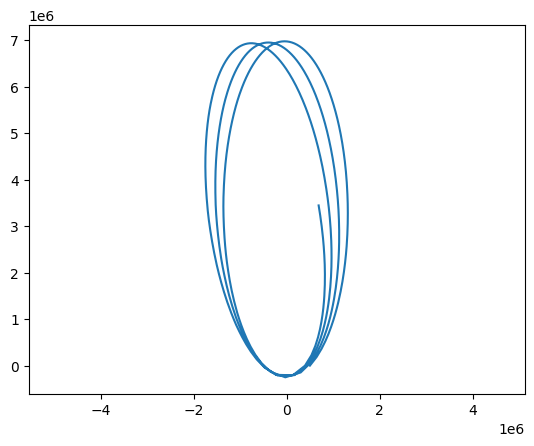

In [34]:
plt.plot(xs, ys)
plt.axis('equal')